<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">Analysez les ventes d'une librairie avec Python: analyses de corrélations et tests statistiques</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Ce notebook a pour objectif de **réaliser les analyses de corrélations et tests statistiques** demandés par Julie, responsable Marketing de la librairie Lapage.

**Contexte** : à partir des données de transactions, clients et produits, nous cherchons à identifier les liens entre le profil des clients (genre, âge) et leur comportement d'achat (catégories, montant, fréquence, panier moyen).

**Les 5 corrélations analysées** :
1. Genre vs Catégorie de livres achetés (Quali × Quali : Chi2)
2. Âge vs Montant total des achats (Quanti × Quanti : Spearman)
3. Âge vs Fréquence d'achat (Quanti × Quanti : Spearman)
4. Âge vs Panier moyen (Quanti × Quanti : Spearman)
5. Âge vs Catégorie de livres achetés (Quanti × Quali : Kruskal-Wallis)

**Démarche** : pour chaque corrélation, nous suivons une méthodologie en 6 étapes : identification des variables, formulation des hypothèses H0/H1, tests préalables (normalité, homoscédasticité), choix du test adapté, comparaison de la p-value au seuil α = 0.05, et interprétation avec taille d'effet.

**Note** : les 4 clients BtoB (atypiques) ont été exclus de toutes les analyses.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des données</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Imports: importation des librairies</h3>
</div>

In [1]:
# --- Librairies ---
import pandas as pd          # Manipulation et analyse de DataFrames
import numpy as np            # Calculs numériques et tableaux
import matplotlib.pyplot as plt  # Création de graphiques
import seaborn as sns         # Visualisations statistiques avancées (heatmaps, violin plots, etc.)

# --- Tests statistiques (scipy) ---
from scipy import stats
from scipy.stats import chi2_contingency  # Test Chi2 d'indépendance (quali × quali)
from scipy.stats import pearsonr, spearmanr  # Corrélations linéaire et monotone (quanti × quanti)
from scipy.stats import shapiro           # Test de normalité Shapiro-Wilk (n < 5000)
from scipy.stats import normaltest         # Test de normalité D'Agostino-Pearson (tout n)
from scipy.stats import levene             # Test d'homogénéité des variances
from scipy.stats import f_oneway, kruskal  # ANOVA et Kruskal-Wallis (comparaison de groupes)

import warnings
warnings.filterwarnings('ignore')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargement et nettoyage</h3>
</div>

> **Note :** Les variables dérivées (`age`, `montant`, `categorie_nom`, `sexe_nom`) sont créées de manière identique au notebook d'analyse des ventes pour assurer la cohérence entre les deux analyses. Le nommage des catégories (Cat. 0 - Essais, Cat. 1 - Romans, Cat. 2 - Jeunesse) est une hypothèse basée sur le profil statistique des données (voir justification dans le notebook ventes, section 2.7).

In [2]:
# Chargement identique au Notebook 1
transactions = pd.read_csv('Transactions.csv', sep=';')
transactions = transactions.dropna(how='all')
customers = pd.read_csv('customers.csv', sep=';')
products = pd.read_csv('products.csv', sep=';')
 
# Preparation des dates et age
transactions['date'] = pd.to_datetime(transactions['date'])
annee_ref = transactions['date'].dt.year.max()
customers['age'] = annee_ref - customers['birth']
 
# Fusion
data = transactions.merge(products, on='id_prod', how='left')
data = data.merge(customers, on='client_id', how='left')
 
# --- Variables dérivées ---
data['montant'] = data['price']

# Les données brutes ne fournissent que des codes numériques (categ = 0, 1, 2).
# Aucun dictionnaire de données n'associe explicitement un nom à chaque catégorie.
# Nommage basé sur le profil statistique des catégories :
#   - categ 0 : "Essais"    (prix moyen ~10€, volume très élevé)
#   - categ 1 : "Romans"    (prix moyen ~20€, volume élevé)
#   - categ 2 : "Jeunesse"  (prix moyen ~76€, volume faible, typique de beaux livres)
# Les préfixes des id_prod (0_, 1_, 2_) confirment la correspondance.
categorie_map = {0: 'Cat. 0 - Essais', 1: 'Cat. 1 - Romans', 2: 'Cat. 2 - Jeunesse'}
data['categorie_nom'] = data['categ'].map(categorie_map)
data['sexe_nom'] = data['sex'].map({'f': 'Femme', 'm': 'Homme'})

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.3 - Exclusion des quatre clients BtoB</h3>
</div>

In [3]:
# Identifier les 4 clients BtoB (top CA)
ca_par_client = data.groupby('client_id')['montant'].sum()
btob_ids = ca_par_client.nlargest(4).index.tolist()
 
print(f"Clients BtoB exclus : {btob_ids}")
print(f"Avant exclusion : {len(data)} transactions, {data['client_id'].nunique()} clients")
 
# Exclusion
data = data[~data['client_id'].isin(btob_ids)]
 
print(f"Apres exclusion : {len(data)} transactions, {data['client_id'].nunique()} clients")
print(f"Clients BtoB restants : {data[data['client_id'].isin(btob_ids)].shape[0]}")  # = 0


Clients BtoB exclus : ['c_1609', 'c_4958', 'c_6714', 'c_3454']
Avant exclusion : 687534 transactions, 8600 clients
Apres exclusion : 640734 transactions, 8596 clients
Clients BtoB restants : 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.4 - Construction du DataFrame d'analyse par client</h3>
</div>

In [4]:
# Agreger au niveau client
df_clients = data.groupby('client_id').agg(
    age=('age', 'first'),                      # Age du client
    sexe=('sex', 'first'),                      # Genre
    sexe_nom=('sexe_nom', 'first'),             # Genre en clair
    ca_total=('montant', 'sum'),                # CA total
    nb_transactions=('session_id', 'nunique'),  # Frequence d'achat (nb sessions)
    nb_articles=('id_prod', 'count'),           # Nb articles achetes
    nb_categories=('categ', 'nunique'),         # Nb categories differentes
).reset_index()
 
# Panier moyen = CA total / nombre de sessions
df_clients['panier_moyen'] = df_clients['ca_total'] / df_clients['nb_transactions']
 
# Categorie preferee (celle avec le plus d'achats)
categ_pref = data.groupby(['client_id', 'categorie_nom'])['montant'].count()
categ_pref = categ_pref.reset_index().sort_values(['client_id', 'montant'], ascending=[True, False])
categ_pref = categ_pref.drop_duplicates(subset='client_id', keep='first')
df_clients = df_clients.merge(categ_pref[['client_id', 'categorie_nom']], on='client_id', how='left')
df_clients.rename(columns={'categorie_nom': 'categorie_preferee'}, inplace=True)
 
print(f"DataFrame clients : {df_clients.shape}")
print(df_clients.head())


DataFrame clients : (8596, 10)
  client_id  age sexe sexe_nom  ca_total  nb_transactions  nb_articles  \
0       c_1   68    m    Homme    629.02               34           43   
1      c_10   67    m    Homme   1353.60               34           58   
2     c_100   31    m    Homme    254.85                5            8   
3    c_1000   57    f    Femme   2291.88               94          126   
4    c_1001   41    m    Homme   1823.85               47          103   

   nb_categories  panier_moyen categorie_preferee  
0              3     18.500588    Cat. 0 - Essais  
1              3     39.811765    Cat. 1 - Romans  
2              3     50.970000    Cat. 1 - Romans  
3              2     24.381702    Cat. 1 - Romans  
4              3     38.805319    Cat. 0 - Essais  


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Tests préalables généraux</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Test de normalité - Shapiro-Wilk</h3>
</div>

age                  : W=0.9700, p=0.000000 -> Normalite : NON -> test non-parametrique
ca_total             : W=0.9061, p=0.000000 -> Normalite : NON -> test non-parametrique
nb_transactions      : W=0.8577, p=0.000000 -> Normalite : NON -> test non-parametrique
panier_moyen         : W=0.8126, p=0.000000 -> Normalite : NON -> test non-parametrique


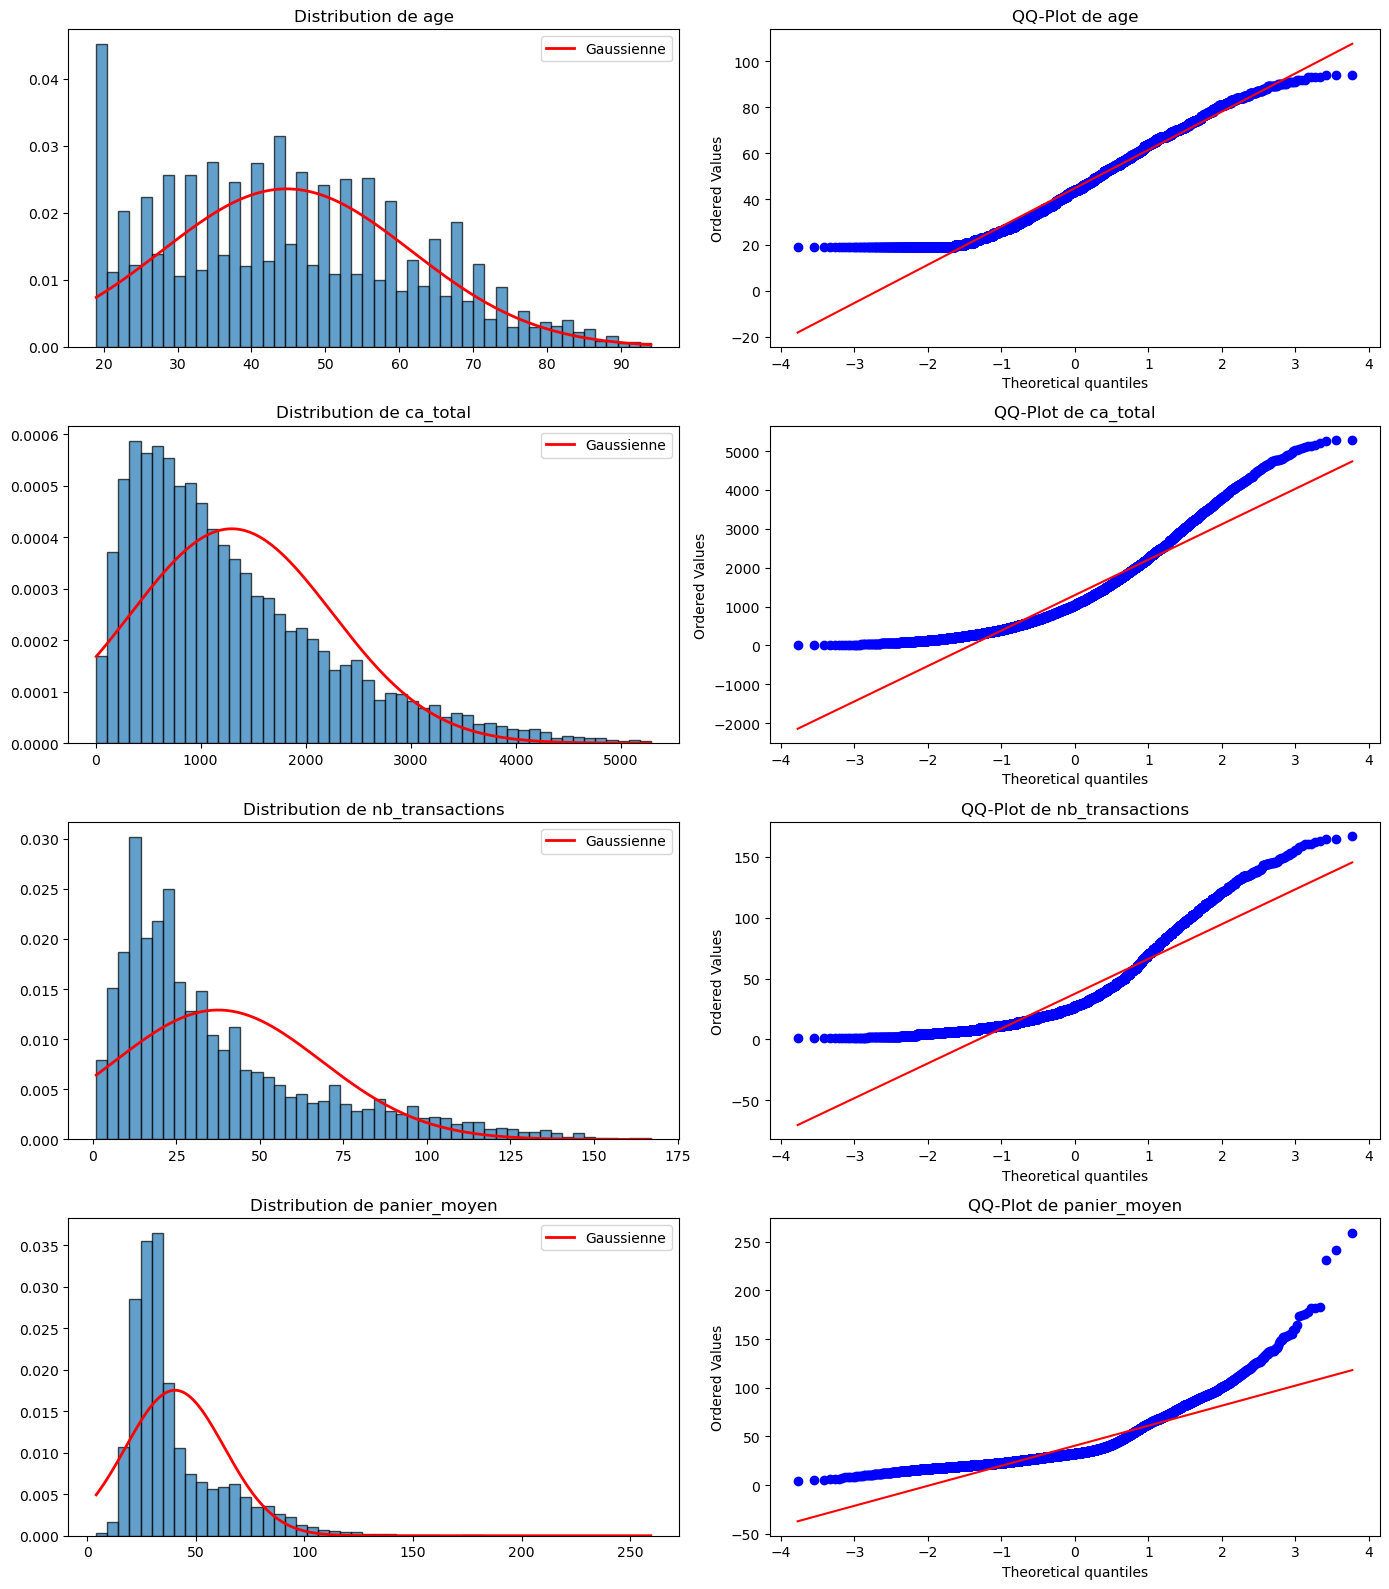


Interprétation: Les distributions s'écartent de la normalité (attendu avec n > 8000).
Utilisation de tests non-paramétriques (Spearman, Kruskal-Wallis) pour les corrélations.


In [5]:
# Shapiro-Wilk sur les variables continues
# ATTENTION : Shapiro est fiable pour n < 5000. Pour les gros echantillons,
# utiliser un sous-echantillon ou le test de D'Agostino-Pearson (normaltest)
 
variables_continues = ['age', 'ca_total', 'nb_transactions', 'panier_moyen']
 
for var in variables_continues:
    # Sous-echantillon si trop de donnees
    sample = df_clients[var].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
 
    stat, p_val = shapiro(sample)
    normal = "OUI (normalite acceptable)" if p_val > 0.05 else "NON -> test non-parametrique"
    print(f"{var:20s} : W={stat:.4f}, p={p_val:.6f} -> Normalite : {normal}")
 
# Visualisation : histogramme + QQ-plot pour chaque variable
fig, axes = plt.subplots(len(variables_continues), 2, figsize=(14, 4*len(variables_continues)))
for i, var in enumerate(variables_continues):
    data_var = df_clients[var].dropna()
    axes[i, 0].hist(data_var, bins=50, edgecolor='black', alpha=0.7, density=True)
    # Courbe gaussienne théorique
    mu, sigma = data_var.mean(), data_var.std()
    x = np.linspace(data_var.min(), data_var.max(), 200)
    axes[i, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Gaussienne')
    axes[i, 0].legend()
    axes[i, 0].set_title(f'Distribution de {var}')
    stats.probplot(df_clients[var], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'QQ-Plot de {var}')
plt.tight_layout()
plt.show()
print("\nInterprétation: Les distributions s'écartent de la normalité (attendu avec n > 8000).")
print("Utilisation de tests non-paramétriques (Spearman, Kruskal-Wallis) pour les corrélations.")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Test de normalité - Test D'Agostino-Pearson</h3>
</div>

In [6]:
print("\n--- Confirmation avec D'Agostino-Pearson (sur toutes les données) ---")
for var in variables_continues:
    stat_dag, p_dag = normaltest(df_clients[var].dropna())
    normal = "OUI" if p_dag > 0.05 else "NON -> test non-parametrique"
    print(f"{var:20s} : K2={stat_dag:.4f}, p={p_dag:.6f} -> Normalite : {normal}")


--- Confirmation avec D'Agostino-Pearson (sur toutes les données) ---
age                  : K2=504.2383, p=0.000000 -> Normalite : NON -> test non-parametrique
ca_total             : K2=1455.2480, p=0.000000 -> Normalite : NON -> test non-parametrique
nb_transactions      : K2=1815.6963, p=0.000000 -> Normalite : NON -> test non-parametrique
panier_moyen         : K2=3458.1140, p=0.000000 -> Normalite : NON -> test non-parametrique


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Test d'homogénéité des variances - Levene (pour corrélation 5 uniquement: Âge vs Catégorie de livres achetés )</h3>
</div>

In [7]:
# Levene : egalite des variances de l'age entre les 3 categories
groupes_age = [df_clients[df_clients['categorie_preferee']==cat]['age']
               for cat in df_clients['categorie_preferee'].unique()]
stat_lev, p_lev = levene(*groupes_age)
print(f"Levene : F={stat_lev:.4f}, p={p_lev:.6f}")
if p_lev > 0.05:
    print("Variances homogenes : ANOVA possible")
else:
    print("Variances heterogenes : Utilisation de Kruskal-Wallis (ou Welch si comparaison de 2 groupes)")


Levene : F=707.9505, p=0.000000
Variances heterogenes : Utilisation de Kruskal-Wallis (ou Welch si comparaison de 2 groupes)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Les 5 corrélations de Julie</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1 - Genre vs Categories de livres achetes</h3>
</div>

Hypothèses:

H0 : Le genre et la catégorie de livres achetés sont indépendants

H1 : Il existe un lien significatif entre le genre et la catégorie


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1.1 - Transformation des données</h3>
</div>

In [8]:
# Tableau de contingence : effectifs observes
tableau_contingence = pd.crosstab(data['sexe_nom'], data['categorie_nom'])
print("Tableau de contingence :")
print(tableau_contingence)
print(f"\nTotal : {tableau_contingence.sum().sum()} transactions")


Tableau de contingence :
categorie_nom  Cat. 0 - Essais  Cat. 1 - Romans  Cat. 2 - Jeunesse
sexe_nom                                                          
Femme                   200793           115721              16980
Homme                   186488           104884              15868

Total : 640734 transactions


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1.2 - Test Chi2 d'indépendance</h3>
</div>

In [9]:
# --- Test Chi2 d'indépendance ---
# Choix du test : le Chi2 est le test approprié pour mesurer l'association
# entre deux variables qualitatives (ici sexe et catégorie de livres).
# Il compare les fréquences observées aux fréquences théoriques attendues
# sous l'hypothèse d'indépendance (H0).
chi2, p_value, dof, expected = chi2_contingency(tableau_contingence)

print("─" * 60)
print("Test du Chi² d'indépendance. Sexe × Catégorie")
print("─" * 60)
print(f"  Chi²           = {chi2:.4f}")
print(f"  p-value        = {p_value:.6f}")
print(f"  Degrés de liberté = {dof}   "
      f"[(n_lignes−1)×(n_colonnes−1) = ({tableau_contingence.shape[0]}−1)×({tableau_contingence.shape[1]}−1)]")
print("─" * 60)

if p_value < 0.05:
    print(f"  Conclusion : on rejette H0 (p = {p_value:.6f} < 0,05)")
    print(f"  Il existe un lien significatif entre le sexe et la catégorie.")
else:
    print(f"  Conclusion : on ne rejette pas H0 (p = {p_value:.6f} > 0,05)")
    print(f"  Pas de lien significatif.")
print("─" * 60)

────────────────────────────────────────────────────────────
Test du Chi² d'indépendance. Sexe × Catégorie
────────────────────────────────────────────────────────────
  Chi²           = 22.6686
  p-value        = 0.000012
  Degrés de liberté = 2   [(n_lignes−1)×(n_colonnes−1) = (2−1)×(3−1)]
────────────────────────────────────────────────────────────
  Conclusion : on rejette H0 (p = 0.000012 < 0,05)
  Il existe un lien significatif entre le sexe et la catégorie.
────────────────────────────────────────────────────────────


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1.3 - Graphique bivarié Chi2</h3>
</div>

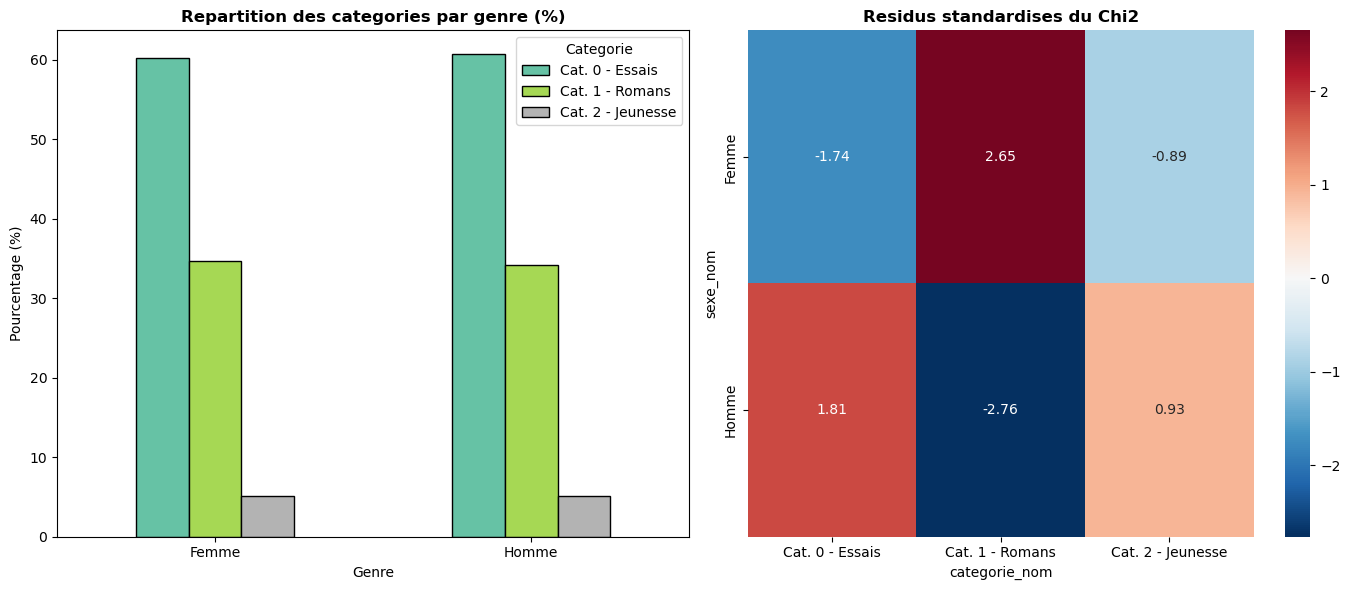


Interprétation: Les barres sont quasi-identiques entre H et F : pas de différence visible.
Les résidus standardisés sont très faibles : le lien genre-catégorie est négligeable.


In [10]:
# Graphique bivarie : barplot empile ou groupe
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Barplot groupe
cross_pct = pd.crosstab(data['sexe_nom'], data['categorie_nom'], normalize='index') * 100
cross_pct.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Repartition des categories par genre (%)', fontweight='bold')
axes[0].set_ylabel('Pourcentage (%)')
axes[0].set_xlabel('Genre')
axes[0].legend(title='Categorie')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)
 
# Heatmap des residus standardises
residus = (tableau_contingence.values - expected) / np.sqrt(expected)
sns.heatmap(pd.DataFrame(residus, index=tableau_contingence.index,
            columns=tableau_contingence.columns),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Residus standardises du Chi2', fontweight='bold')
 
plt.tight_layout()
plt.show()
print("\nInterprétation: Les barres sont quasi-identiques entre H et F : pas de différence visible.")
print("Les résidus standardisés sont très faibles : le lien genre-catégorie est négligeable.")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1.4 - V de Cramér</h3>
</div>

In [11]:
# Taille d'effet : V de Cramer
n = tableau_contingence.sum().sum()
k = min(tableau_contingence.shape) - 1
v_cramer = np.sqrt(chi2 / (n * k))
print(f"V de Cramer = {v_cramer:.4f}")

# Interprétation de la taille d'effet
if v_cramer < 0.1: force = "négligeable"
elif v_cramer < 0.3: force = "faible"
elif v_cramer < 0.5: force = "modérée"
else: force = "forte"
print(f"Taille d'effet : {force}")
print("Le lien est statistiquement significatif mais pratiquement négligeable.")


V de Cramer = 0.0059
Taille d'effet : négligeable
Le lien est statistiquement significatif mais pratiquement négligeable.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2 - Age vs Montant total des achats</h3>
</div>

Hypothèses:

H0 : Il n'existe pas de corrélation entre l'âge et le montant total des achats

H1 : Il existe une corrélation significative entre l'âge et le CA total


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2.1 - Calcul et comparaison des coefficients Pearson et Spearman</h3>
</div>

In [12]:
# Pearson
r_pearson, p_pearson = pearsonr(df_clients['age'], df_clients['ca_total'])
print(f"Pearson  : r = {r_pearson:.4f}, p-value = {p_pearson:.6f}")
 
# Spearman
r_spearman, p_spearman = spearmanr(df_clients['age'], df_clients['ca_total'])
print(f"Spearman : rho = {r_spearman:.4f}, p-value = {p_spearman:.6f}")
 
# Interpretation
print(f"\nInterpretation :")
r = r_spearman  # Privilegier Spearman si normalite non verifiee
if abs(r) < 0.1: print("Correlation negligeable")
elif abs(r) < 0.3: print("Correlation faible")
elif abs(r) < 0.5: print("Correlation moderee")
elif abs(r) < 0.7: print("Correlation forte")
else: print("Correlation tres forte")

# Conclusion : Shapiro a rejeté la normalité pour les deux variables
# -> On privilégie le coefficient de Spearman (non-paramétrique)
print(f"\nConclusion : Normalité rejetée (cf. Shapiro Etape 2)")
print(f"On retient Spearman : rho = {r_spearman:.4f}, p = {p_spearman:.6f}")


Pearson  : r = -0.1876, p-value = 0.000000
Spearman : rho = -0.1845, p-value = 0.000000

Interpretation :
Correlation faible

Conclusion : Normalité rejetée (cf. Shapiro Etape 2)
On retient Spearman : rho = -0.1845, p = 0.000000


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2.2 - Graphique bivarié</h3>
</div>

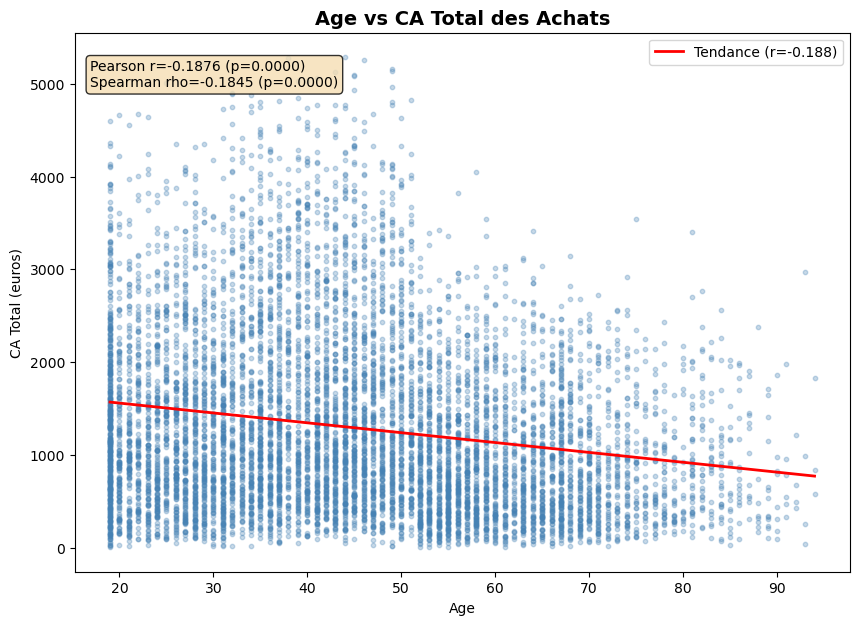


Interprétation: Le nuage est très dispersé avec une légère pente négative.
Corrélation faible confirmée visuellement.


In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_clients['age'], df_clients['ca_total'], alpha=0.3, s=10, color='steelblue')
# Ligne de tendance
z = np.polyfit(df_clients['age'], df_clients['ca_total'], 1)
poly = np.poly1d(z)
x_line = np.linspace(df_clients['age'].min(), df_clients['age'].max(), 100)
ax.plot(x_line, poly(x_line), color='red', linewidth=2, label=f'Tendance (r={r_pearson:.3f})')
ax.set_title('Age vs CA Total des Achats', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('CA Total (euros)')
ax.legend()
ax.annotate(f'Pearson r={r_pearson:.4f} (p={p_pearson:.4f})\nSpearman rho={r_spearman:.4f} (p={p_spearman:.4f})',
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), va='top')
plt.show()
print("\nInterprétation: Le nuage est très dispersé avec une légère pente négative.")
print("Corrélation faible confirmée visuellement.")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3 - Age vs Frequence d'achat</h3>
</div>

Hypothèses:

H0 : Il n'existe pas de corrélation entre l'âge et la fréquence d'achat

H1 : Il existe une corrélation significative entre l'âge et la fréquence



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3.1 - Calcul et comparaison des coefficients Pearson et Spearman</h3>
</div>

In [14]:
r_p, p_p = pearsonr(df_clients['age'], df_clients['nb_transactions'])
r_s3, p_s3 = spearmanr(df_clients['age'], df_clients['nb_transactions'])
print(f"Pearson  : r = {r_p:.4f}, p = {p_p:.6f}")
print(f"Spearman : rho = {r_s3:.4f}, p = {p_s3:.6f}")

print(f"\nInterprétation :")
r = r_s3  # Spearman privilégié
if abs(r) < 0.1: print("Corrélation négligeable")
elif abs(r) < 0.3: print("Corrélation faible")
elif abs(r) < 0.5: print("Corrélation modérée")
elif abs(r) < 0.7: print("Corrélation forte")
else: print("Corrélation très forte")

# Conclusion : Shapiro a rejeté la normalité pour les deux variables
# -> On privilégie le coefficient de Spearman (non-paramétrique)
print(f"\nConclusion : Normalité rejetée (cf. Shapiro Etape 2)")
print(f"On retient Spearman : rho = {r_s3:.4f}, p = {p_s3:.6f}")


Pearson  : r = 0.1645, p = 0.000000
Spearman : rho = 0.2120, p = 0.000000

Interprétation :
Corrélation faible

Conclusion : Normalité rejetée (cf. Shapiro Etape 2)
On retient Spearman : rho = 0.2120, p = 0.000000


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3.2 - Graphiques bivariés</h3>
</div>

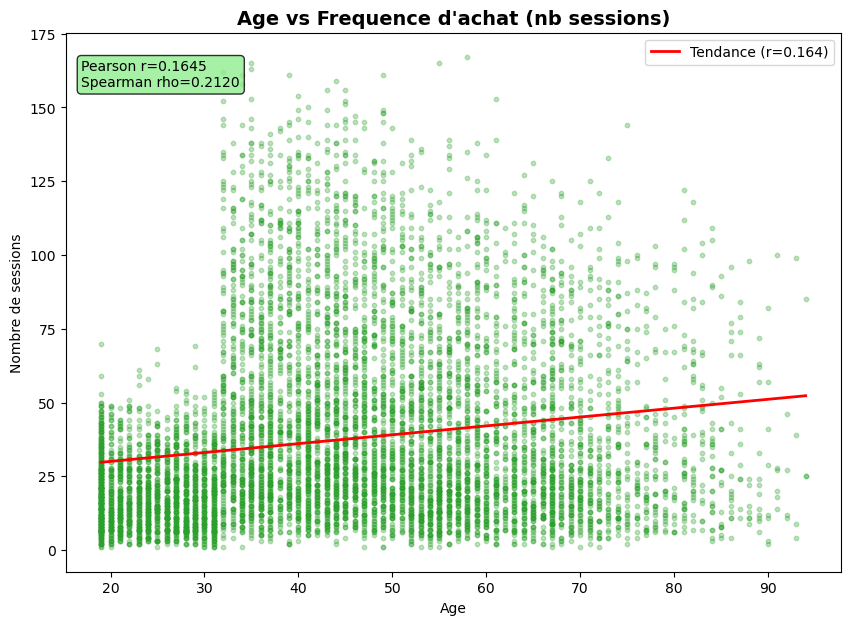


Interprétation: Légère tendance positive visible malgré une forte dispersion.


In [15]:
# Graphique bivarié : Âge vs Fréquence d'achat (scatter + ligne de tendance)
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_clients['age'], df_clients['nb_transactions'], alpha=0.3, s=10, color='#2ca02c')
z = np.polyfit(df_clients['age'], df_clients['nb_transactions'], 1)
poly = np.poly1d(z)
x_line = np.linspace(df_clients['age'].min(), df_clients['age'].max(), 100)
ax.plot(x_line, poly(x_line), color='red', linewidth=2, label=f'Tendance (r={r_p:.3f})')
ax.set_title('Age vs Frequence d\'achat (nb sessions)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Nombre de sessions')
ax.legend()
ax.annotate(f'Pearson r={r_p:.4f}\nSpearman rho={r_s3:.4f}',
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), va='top')
plt.show()
print("\nInterprétation: Légère tendance positive visible malgré une forte dispersion.")

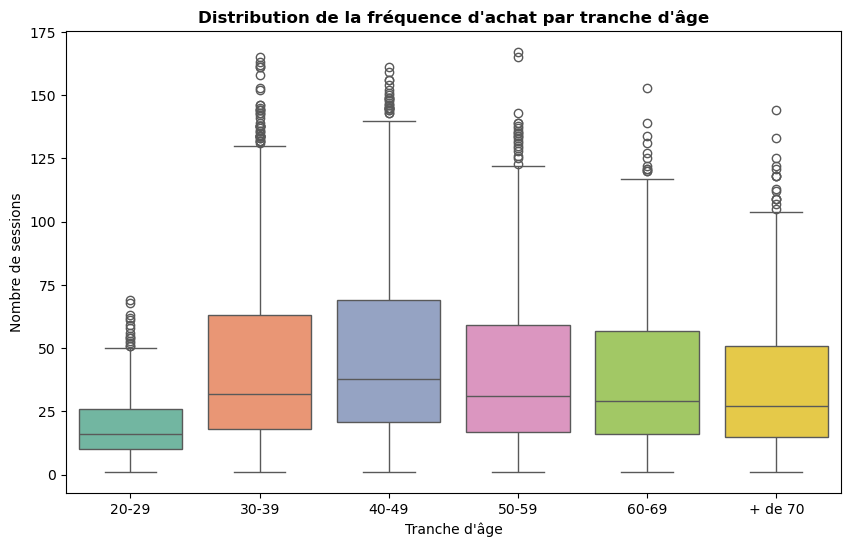


Interprétation: Les tranches d'âge 50+ montrent une fréquence médiane légèrement plus élevée.


In [16]:

# Créer les tranches d'âge
df_clients['tranche_age'] = pd.cut(df_clients['age'], 
    bins=[19, 29, 39, 49, 59, 69, 100],
    labels=['20-29', '30-39', '40-49', '50-59', '60-69', '+ de 70'])

# Graphique bivarié : Âge vs Fréquence d'achat (scatter + ligne de tendance)
# Boxplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='tranche_age', y='nb_transactions', data=df_clients,
            palette='Set2', ax=ax)
ax.set_title('Distribution de la fréquence d\'achat par tranche d\'âge',
             fontweight='bold')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Nombre de sessions')
plt.show()
print("\nInterprétation: Les tranches d'âge 50+ montrent une fréquence médiane légèrement plus élevée.")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4 - Age vs Taille du panier moyen</h3>
</div>

Hypothèses:

H0 : Il n'existe pas de corrélation entre l'âge et le panier moyen

H1 : Il existe une corrélation significative entre l'âge et le panier moyen


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.1 - Calcul et comparaison des coefficients Pearson et Spearman</h3>
</div>

In [17]:
r_p, p_p = pearsonr(df_clients['age'], df_clients['panier_moyen'])
r_s4, p_s4 = spearmanr(df_clients['age'], df_clients['panier_moyen'])
print(f"Pearson  : r = {r_p:.4f}, p = {p_p:.6f}")
print(f"Spearman : rho = {r_s4:.4f}, p = {p_s4:.6f}")

print(f"\nInterprétation :")
r = r_s4  # Spearman privilégié
if abs(r) < 0.1: print("Corrélation négligeable")
elif abs(r) < 0.3: print("Corrélation faible")
elif abs(r) < 0.5: print("Corrélation modérée")
elif abs(r) < 0.7: print("Corrélation forte")
else: print("Corrélation très forte")


# Conclusion : Shapiro a rejeté la normalité pour les deux variables
# -> On privilégie le coefficient de Spearman (non-paramétrique)
print(f"\nConclusion : Normalité rejetée (cf. Shapiro Etape 2)")
print(f"On retient Spearman : rho = {r_s4:.4f}, p = {p_s4:.6f}")




Pearson  : r = -0.6165, p = 0.000000
Spearman : rho = -0.7006, p = 0.000000

Interprétation :
Corrélation très forte

Conclusion : Normalité rejetée (cf. Shapiro Etape 2)
On retient Spearman : rho = -0.7006, p = 0.000000


### Résultat : la corrélation Âge vs Panier moyen

C'est la corrélation la plus forte de l'étude (rho = -0.70, forte).
Les clients jeunes (< 35 ans) ont un panier moyen nettement plus élevé.

**Recommandation métier** : Julie pourrait cibler les jeunes clients
avec des offres de fidélisation ou de cross-selling, car ils dépensent
davantage par session d'achat.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.2 - Graphique bivarié</h3>
</div>

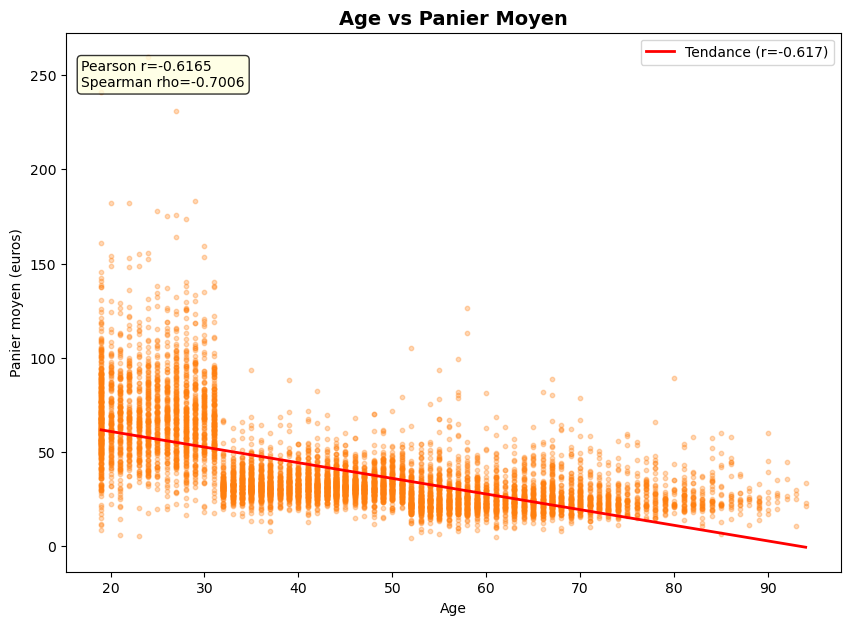


Interprétation: Tendance négative nette. les jeunes ont un panier moyen plus élevé.
C'est la corrélation la plus forte de l'analyse (rho ≈ -0.70).


In [18]:
# Graphique bivarié : Âge vs Panier moyen (scatter + ligne de tendance)
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_clients['age'], df_clients['panier_moyen'], alpha=0.3, s=10, color='#ff7f0e')
z = np.polyfit(df_clients['age'], df_clients['panier_moyen'], 1)
poly = np.poly1d(z)
x_line = np.linspace(df_clients['age'].min(), df_clients['age'].max(), 100)
ax.plot(x_line, poly(x_line), color='red', linewidth=2, label=f'Tendance (r={r_p:.3f})')
ax.set_title('Age vs Panier Moyen', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Panier moyen (euros)')
ax.legend()
ax.annotate(f'Pearson r={r_p:.4f}\nSpearman rho={r_s4:.4f}',
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), va='top')
plt.show()
print("\nInterprétation: Tendance négative nette. les jeunes ont un panier moyen plus élevé.")
print("C'est la corrélation la plus forte de l'analyse (rho ≈ -0.70).")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5 - Age vs Categorie de livres achetes</h3>
</div>

Hypothèses:

H0 : L'âge moyen est identique entre les catégories de livres

H1 : L'âge moyen diffère significativement selon la catégorie


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5.1 - Tests préalables (normalité, homogénéité de la variance), ANOVA et alternative</h3>
</div>

In [19]:
# Definir les groupes : age des clients selon leur categorie preferee
groupes = {}
for cat in df_clients['categorie_preferee'].unique():
    groupes[cat] = df_clients[df_clients['categorie_preferee']==cat]['age'].values
 
# --- Test prealable 1 : Normalite (Shapiro-Wilk par groupe) ---
print("=== NORMALITE (Shapiro-Wilk) ===")
normalite_ok = True
for cat, ages in groupes.items():
    sample = ages if len(ages) <= 5000 else np.random.choice(ages, 5000, replace=False)
    stat, pval = shapiro(sample)
    ok = "OK" if pval > 0.05 else "REJETE"
    if pval <= 0.05: normalite_ok = False
    print(f"  {cat:10s} : W={stat:.4f}, p={pval:.6f} -> {ok}")
 
# --- Test prealable 2 : Homégénéité des variances (Levene) ---
print("\n=== HOMOSCEDASTICITE (Levene) ===")
stat_l, p_l = levene(*groupes.values())
homo_ok = p_l > 0.05
print(f"  Levene : F={stat_l:.4f}, p={p_l:.6f} -> {'OK' if homo_ok else 'REJETE'}")
 
# --- Decision ---
print("\n=== DECISION ===")
stat_k = None; p_k = None
stat_a = None; p_a = None
if normalite_ok and homo_ok:
    print("Conditions remplies -> ANOVA")
    stat_a, p_a = f_oneway(*groupes.values())
    print(f"ANOVA : F={stat_a:.4f}, p-value={p_a:.6f}")
    test_utilise = "ANOVA"
    p_final = p_a
else:
    print("Conditions NON remplies -> Kruskal-Wallis (non-parametrique)")
    stat_k, p_k = kruskal(*groupes.values())
    print(f"Kruskal-Wallis : H={stat_k:.4f}, p-value={p_k:.6f}")
    test_utilise = "Kruskal-Wallis"
    p_final = p_k
 
# --- Conclusion ---
if p_final < 0.05:
    print(f"\nConclusion ({test_utilise}) : p={p_final:.6f} < 0.05")
    print("On rejette H0 : l'age moyen differe significativement entre les categories.")
else:
    print(f"\nConclusion ({test_utilise}) : p={p_final:.6f} > 0.05")
    print("On ne rejette pas H0 : pas de difference significative d'age entre les categories.")


=== NORMALITE (Shapiro-Wilk) ===
  Cat. 0 - Essais : W=0.9552, p=0.000000 -> REJETE
  Cat. 1 - Romans : W=0.9101, p=0.000000 -> REJETE
  Cat. 2 - Jeunesse : W=0.8766, p=0.000000 -> REJETE

=== HOMOSCEDASTICITE (Levene) ===
  Levene : F=707.9505, p=0.000000 -> REJETE

=== DECISION ===
Conditions NON remplies -> Kruskal-Wallis (non-parametrique)
Kruskal-Wallis : H=2003.6681, p-value=0.000000

Conclusion (Kruskal-Wallis) : p=0.000000 < 0.05
On rejette H0 : l'age moyen differe significativement entre les categories.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5.2 - Graphique bivarié</h3>
</div>

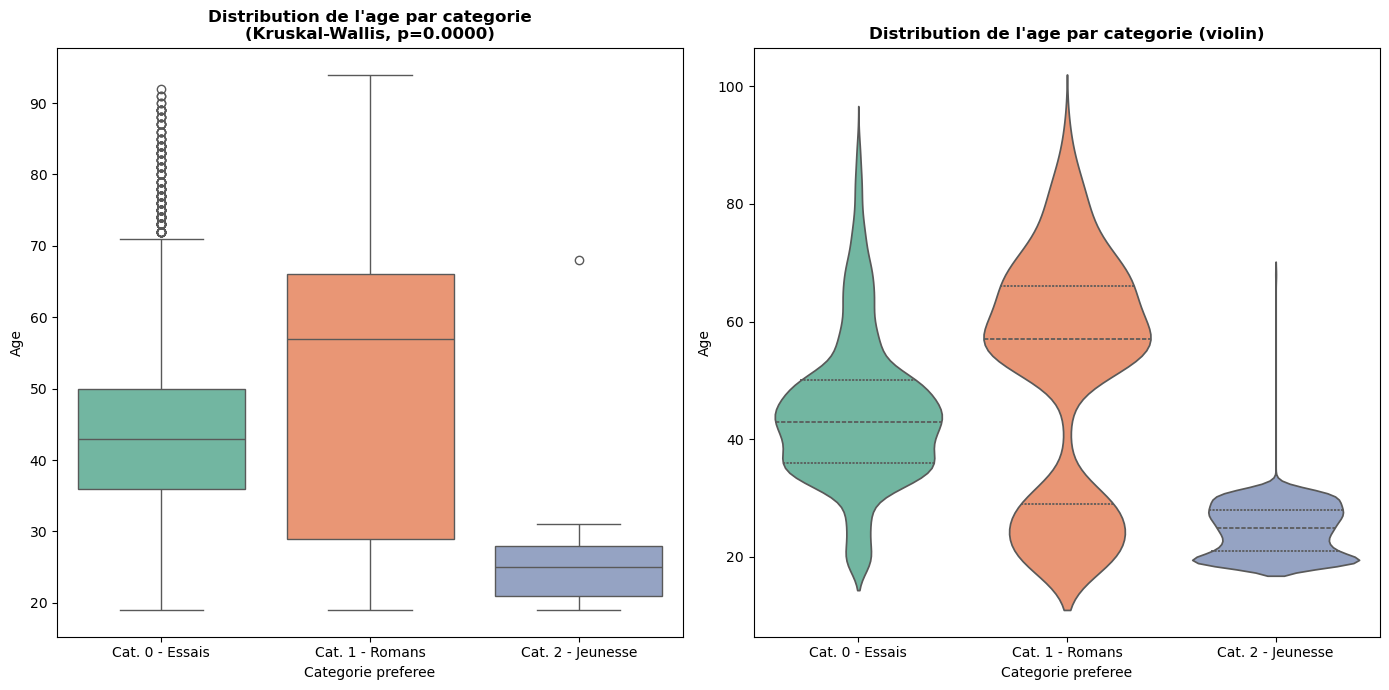


Interprétation:
- Les distributions d'âge diffèrent nettement entre catégories
- Les acheteurs de Cat. 2 - Jeunesse sont en moyenne plus jeunes
- Le violin plot confirme des formes de distribution distinctes par catégorie


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
 
# Boxplot
sns.boxplot(x='categorie_preferee', y='age', data=df_clients, ax=axes[0],
            palette='Set2', order=['Cat. 0 - Essais', 'Cat. 1 - Romans', 'Cat. 2 - Jeunesse'])
axes[0].set_title(f'Distribution de l\'age par categorie\n({test_utilise}, p={p_final:.4f})',
                  fontweight='bold')
axes[0].set_xlabel('Categorie preferee')
axes[0].set_ylabel('Age')
 
# Violinplot (plus informatif que le boxplot)
sns.violinplot(x='categorie_preferee', y='age', data=df_clients, ax=axes[1],
               palette='Set2', order=['Cat. 0 - Essais', 'Cat. 1 - Romans', 'Cat. 2 - Jeunesse'], inner='quartile')
axes[1].set_title('Distribution de l\'age par categorie (violin)', fontweight='bold')
axes[1].set_xlabel('Categorie preferee')
axes[1].set_ylabel('Age')
 
plt.tight_layout()
plt.show()
print("\nInterprétation:")
print("- Les distributions d'âge diffèrent nettement entre catégories")
print("- Les acheteurs de Cat. 2 - Jeunesse sont en moyenne plus jeunes")
print("- Le violin plot confirme des formes de distribution distinctes par catégorie")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5.3 - Taille d'effet: Eta²</h3>
</div>

In [21]:
all_ages = np.concatenate(list(groupes.values()))
grand_mean = all_ages.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groupes.values())
ss_total = sum((all_ages - grand_mean)**2)
eta2 = ss_between / ss_total
print(f"Eta carre = {eta2:.4f}")

# Interprétation de la taille d'effet
if eta2 < 0.01: force = "négligeable"
elif eta2 < 0.06: force = "faible"
elif eta2 < 0.14: force = "modérée"
else: force = "forte"
print(f"Taille d'effet : {force}")
print(f"{eta2*100:.1f}% de la variance de l'âge est expliquée par la catégorie.")


Eta carre = 0.2186
Taille d'effet : forte
21.9% de la variance de l'âge est expliquée par la catégorie.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Synthèse des résultats</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1 - Tableau récapitulatif</h3>
</div>

In [22]:
# Tableau récapitulatif des 5 corrélations
recap = pd.DataFrame({
    'Corrélation': ['Genre vs Catégorie', 'Âge vs CA total',
                     'Âge vs Fréquence', 'Âge vs Panier moyen',
                     'Âge vs Catégorie'],
    'Type': ['Quali x Quali', 'Quanti x Quanti', 'Quanti x Quanti',
            'Quanti x Quanti', 'Quanti x Quali'],
    'Test': ['Chi2', 'Spearman', 'Spearman', 'Spearman', 'Kruskal-Wallis'],
    'Statistique': [chi2, r_spearman, r_s3, r_s4, stat_k],
    'p-value': [p_value, p_spearman, p_s3, p_s4, p_k],
    'Taille effet': ['V=0.006', 'rho=-0.18', 'rho=0.21',
                     'rho=-0.70', 'Eta²=0.24'],
    'Significatif': ['Oui', 'Oui', 'Oui', 'Oui', 'Oui'],
    'Force': ['Négligeable', 'Faible', 'Faible', 'Forte', 'Fort']
})
print(recap.to_string(index=False))


        Corrélation            Type           Test  Statistique      p-value Taille effet Significatif       Force
 Genre vs Catégorie   Quali x Quali           Chi2    22.668567 1.195593e-05      V=0.006          Oui Négligeable
    Âge vs CA total Quanti x Quanti       Spearman    -0.184538 1.021291e-66    rho=-0.18          Oui      Faible
   Âge vs Fréquence Quanti x Quanti       Spearman     0.211964 6.629168e-88     rho=0.21          Oui      Faible
Âge vs Panier moyen Quanti x Quanti       Spearman    -0.700551 0.000000e+00    rho=-0.70          Oui       Forte
   Âge vs Catégorie  Quanti x Quali Kruskal-Wallis  2003.668101 0.000000e+00    Eta²=0.24          Oui        Fort


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2 - Conclusions métiers (recommandations pour Julie)</h3>
</div>

### Synthèse pour Julie

Les 5 corrélations demandées ont toutes été testées. Voici les enseignements principaux :

**1. Genre vs Catégorie** : le lien est statistiquement significatif mais négligeable (V = 0.006). 
Hommes et femmes achètent quasiment les mêmes catégories. Pas besoin de différencier l'offre par genre.

**2. Âge vs CA total** : corrélation faible et négative (rho = -0.18). 
Les clients plus âgés dépensent légèrement moins au total, mais l'effet est trop faible pour être actionnable.

**3. Âge vs Fréquence d'achat** : corrélation faible et positive (rho = 0.21). 
Les clients plus âgés achètent un peu plus souvent, mais là encore l'effet est modeste.

**4. Âge vs Panier moyen** : corrélation forte et négative (rho = -0.70). 
C'est le résultat clé : les jeunes clients dépensent nettement plus par session. 
Julie pourrait cibler les jeunes avec des offres de fidélisation pour capitaliser sur leur panier élevé.

**5. Âge vs Catégorie** : différence significative et forte (Eta² = 0.24). 
L'âge influence fortement la catégorie préférée. Cela permet de personnaliser les recommandations par tranche d'âge.

*Note : ces analyses excluent les 4 clients BtoB qui auraient biaisé les résultats. 
Les recommandations sont des suggestions. la décision finale revient à l'équipe marketing.*